# Binary Tree Rasters From WorldCover or Canopy Height

``worldcover_trees`` and ``canopy_height_trees`` convert tifs into a binary format for the shelter-category pipeline.

In [1]:
from shelterbelts.classifications.binary_trees import worldcover_trees, canopy_height_trees, cmap_woody_veg, labels_woody_veg
from shelterbelts.utils.filepaths import get_filename
from shelterbelts.utils.visualisation import visualise_categories

CPU times: user 1.71 s, sys: 739 ms, total: 2.45 s
Wall time: 4.84 s


## WorldCover to binary tree raster

Classes 10 (Tree cover) and 20 (Shrubland) become 1 and everything else becomes 0.

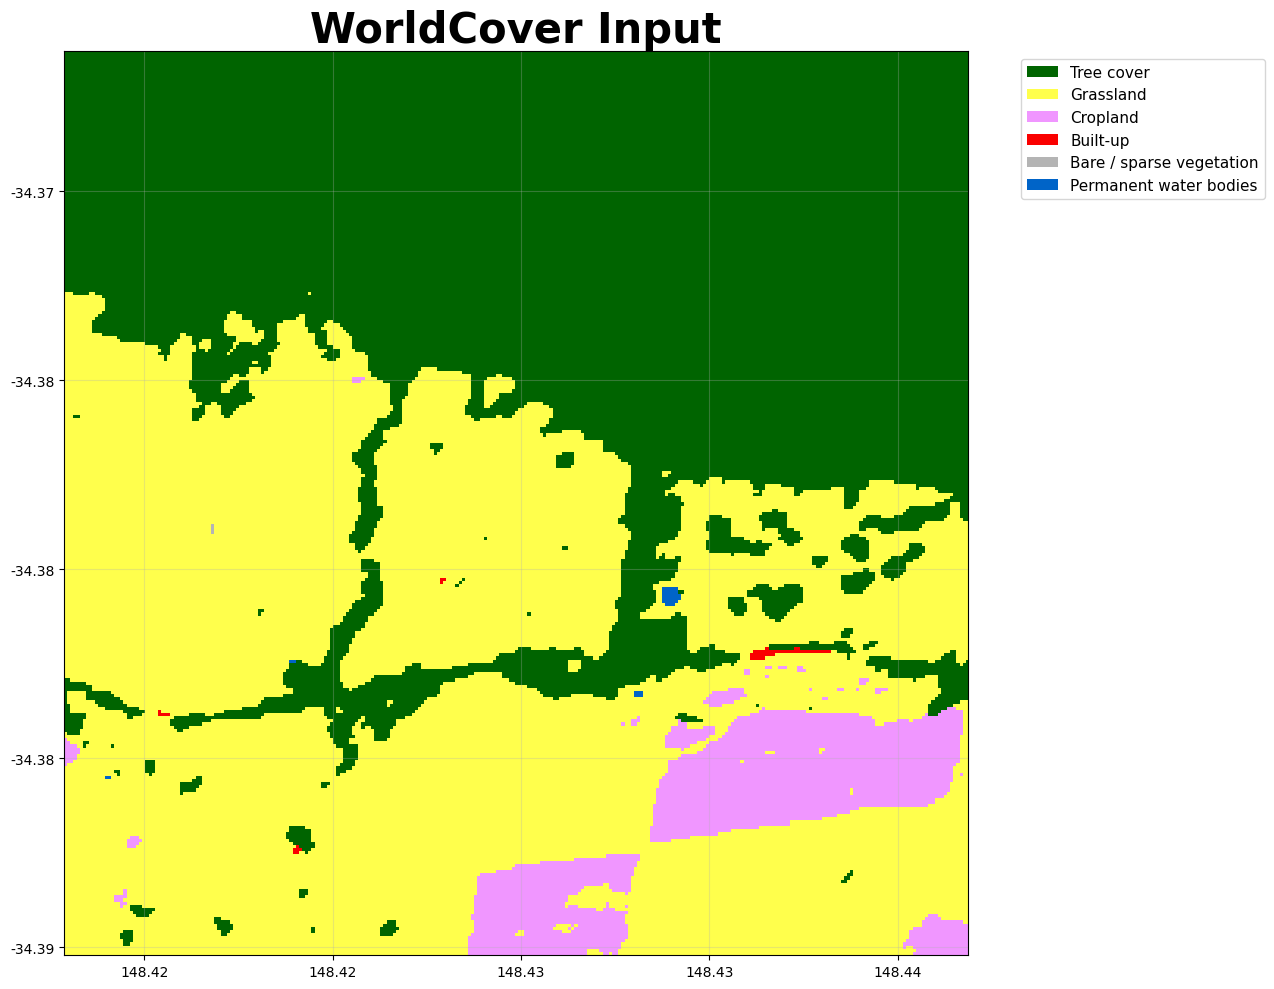

In [2]:
import rioxarray as rxr
from shelterbelts.apis.worldcover import worldcover_cmap, worldcover_labels

filename = get_filename('g2_26729_worldcover.tif')
da_input_worldcover = rxr.open_rasterio(filename).isel(band=0).drop_vars('band')
visualise_categories(da_input_worldcover, colormap=worldcover_cmap, labels=worldcover_labels, title='WorldCover Input')

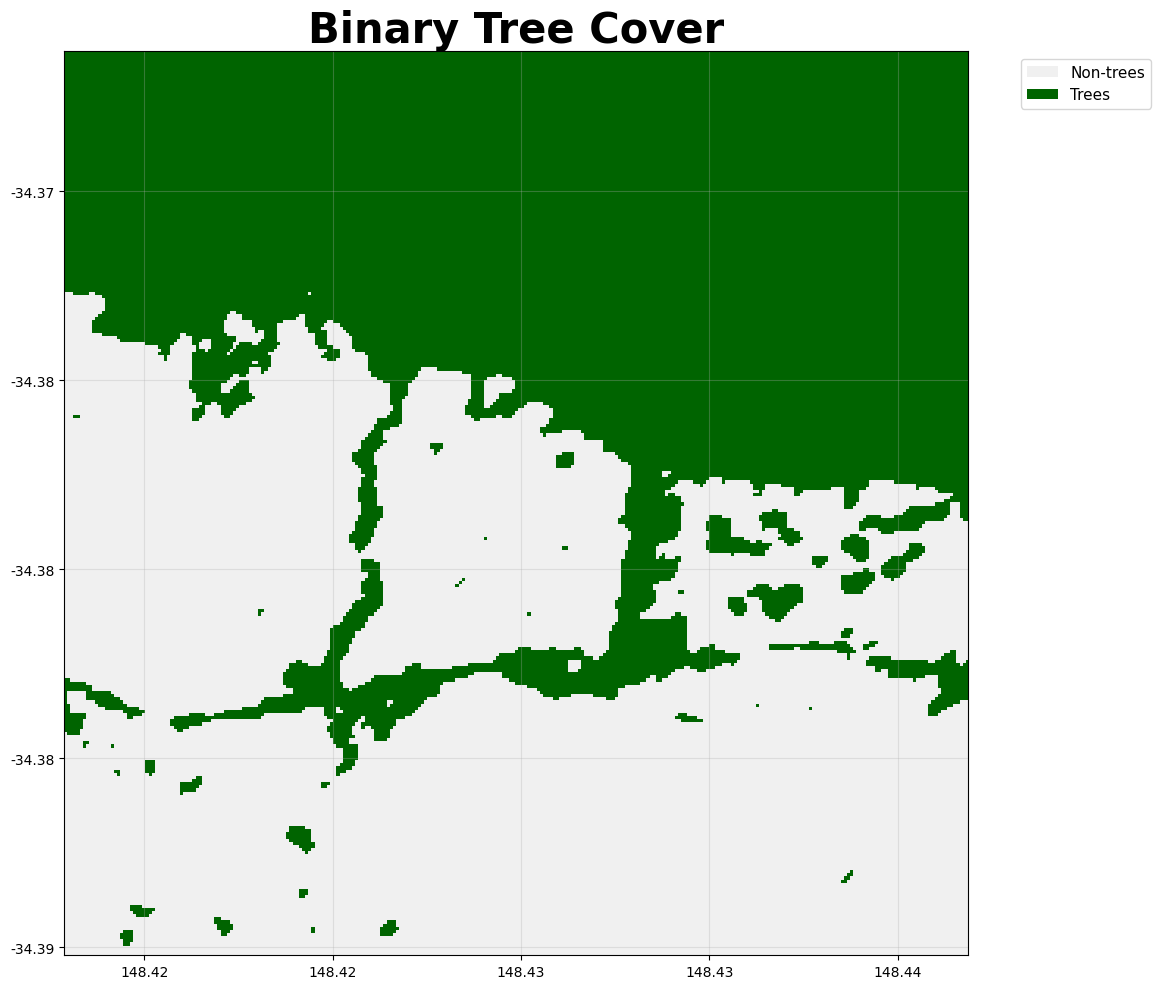

In [3]:
ds = worldcover_trees(filename, savetif=False, plot=False)
visualise_categories(ds['woody_veg'], colormap=cmap_woody_veg, labels=labels_woody_veg, title='Binary Tree Cover')

## Canopy height to binary tree raster

Everything above 1 m becomes a 'tree' pixel, coarsened to 10m using max resampling (note this is a different location to the example above).

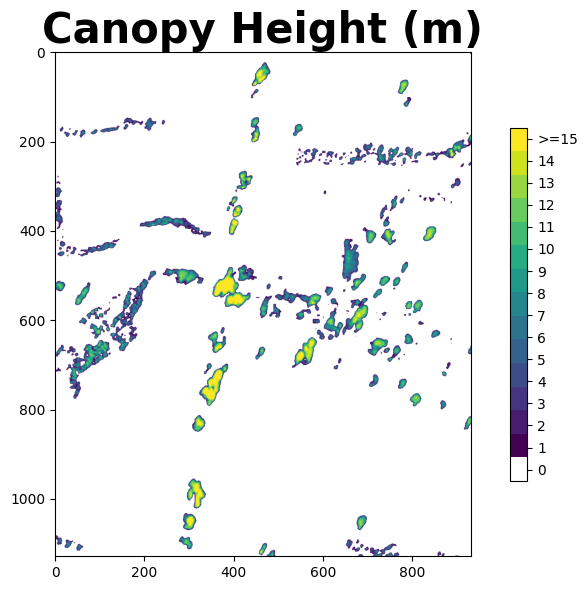

In [4]:
import xarray as xr
from shelterbelts.utils.visualisation import visualise_canopy_height

filename = get_filename('milgadara_1kmx1km_CHM_1m.tif')
da_input_chm = rxr.open_rasterio(filename).isel(band=0).drop_vars('band')
visualise_canopy_height(da_input_chm.to_dataset(name='canopy_height'))

Saved: ./milgadara_1kmx1km_CHM_1m_woody_veg.tif
Saved: ./milgadara_1kmx1km_CHM_1m_woody_veg.png


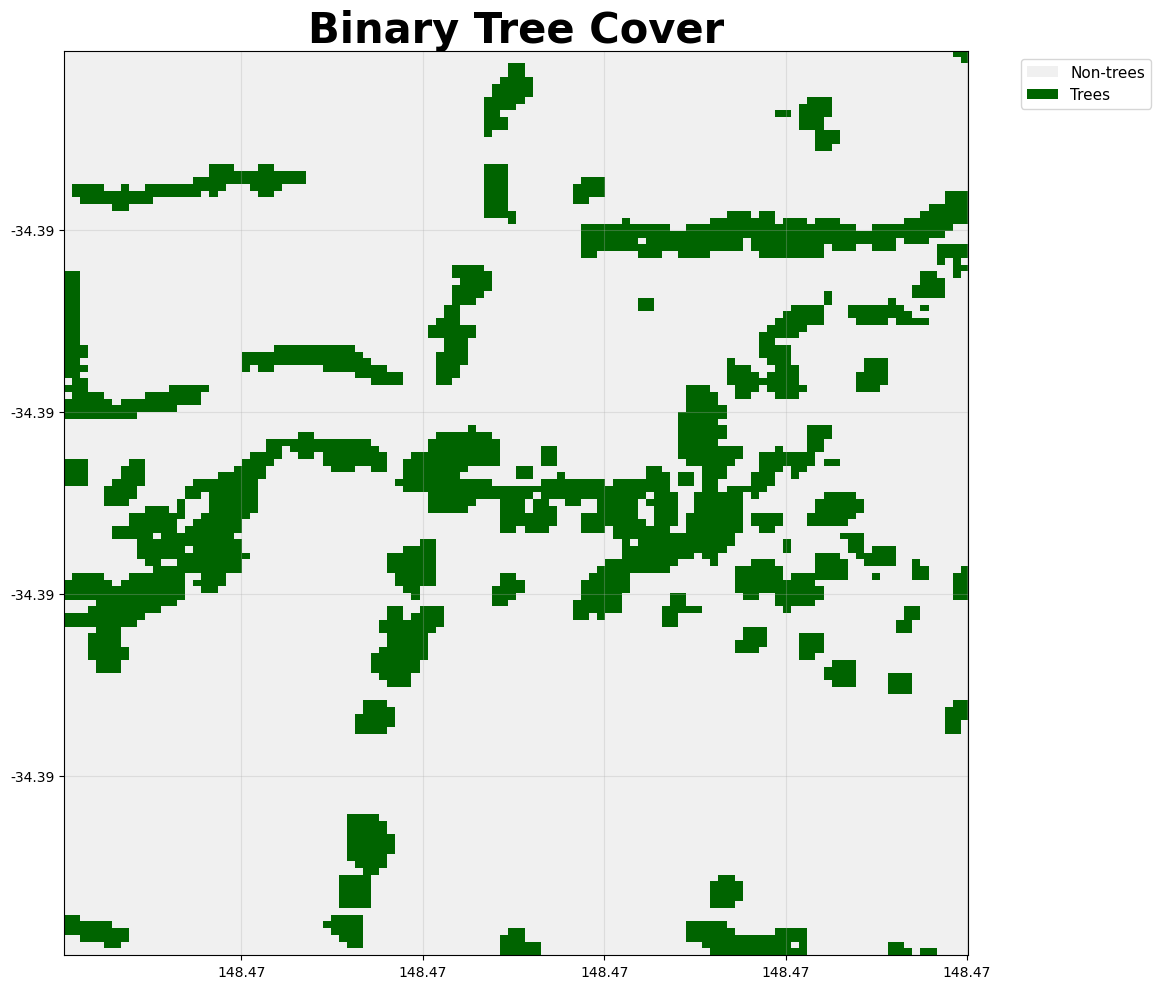

In [5]:
ds = canopy_height_trees(filename)
visualise_categories(ds['woody_veg'], colormap=cmap_woody_veg, labels=labels_woody_veg, title='Binary Tree Cover')